In [46]:
from pathlib import Path
import pandas as pd 
from collections import defaultdict
ROOT = Path("/mnt/ceph-hdd/cold/nim00020/hannibal_data")
csv_dir = ROOT / "eval_models" / "instance_segmentation_results"
result_csvs = list(csv_dir.glob("*.csv"))
metadata_csv = ROOT / "cancerscout_metadata" / "cancerscout_semantic_organized.csv"

In [49]:
print([c for c in result_csvs if "generalist" in c.stem])
type(result_csvs)

[PosixPath('/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001755_1-2-1_HE-2021-10-12T16-06-24_generalist.csv'), PosixPath('/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001945_1-1-1_HE-2021-10-06T09-51-36_generalist.csv'), PosixPath('/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001560_1-1-1_HE-2021-10-12T16-44-02_generalist.csv'), PosixPath('/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001691_1-1-1_HE-2021-10-11T09-39-02_generalist.csv'), PosixPath('/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001498_1-1-1_HE-2021-10-07T09-21-20_generalist.csv'), PosixPath('/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001212_1-1-1_HE-2021-10-08T13-23-40_generalist.csv'), PosixPath('/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/inst

list

In [ ]:
len(result_csvs)
from pprint import pprint
metadata_df = pd.read_csv(metadata_csv, index_col="filename")
# print(metadata_df.index.tolist())
# print(metadata_df.keys())
# print(metadata_df.index.tolist)

all_results = {}

for segmentation_method in ["ais", "apg"]:
    for score in ["Precision", "Recall", "F1", "SA"]:
        results = defaultdict(list)

        for result_csv in result_csvs:
            generalist = "_generalist" in result_csv.name
            if generalist and segmentation_method == "ais":
                continue
            filename = result_csv.stem.strip("_generalist")    
            subtype = metadata_df.loc[filename, "subtype"]
            result_df = pd.read_csv(result_csv)
            results[subtype].append(result_df[f"{segmentation_method}_{score}"])
            results["Threshold"] = result_df["Threshold"]
        

[0    0.915885
1    0.905370
2    0.894291
3    0.883550
4    0.868739
5    0.843075
6    0.797287
7    0.707066
8    0.522103
9    0.181232
Name: ais_Precision, dtype: float64, 0    0.855225
1    0.848514
2    0.841802
3    0.830297
4    0.812081
5    0.790988
6    0.743049
7    0.656759
8    0.473634
9    0.134228
Name: ais_Precision, dtype: float64]
[0    0.912000
1    0.900958
2    0.888789
3    0.877634
4    0.862761
5    0.840338
6    0.791099
7    0.696901
8    0.515268
9    0.174310
Name: apg_Precision, dtype: float64, 0    0.845714
1    0.835238
2    0.820000
3    0.804762
4    0.779048
5    0.751429
6    0.691429
7    0.605714
8    0.404762
9    0.106667
Name: apg_Precision, dtype: float64]


In [50]:
import numpy as np
import pandas as pd
from collections import defaultdict

# Separate dictionaries for complete isolation
specialist_results = {}
generalist_results = {}
static_csv_list = list(result_csvs)
for segmentation_method in ["ais", "apg"]:
    specialist_results[segmentation_method] = {}
    generalist_results[segmentation_method] = {}

    for score in ["Precision", "Recall", "F1", "SA"]:
        spec_dict = defaultdict(list)
        gen_dict = defaultdict(list)

        for result_csv in result_csvs:
            # Check if the file belongs to a generalist model
            is_generalist = "_generalist" in result_csv.name
            if is_generalist and segmentation_method == "ais":
                continue
            
            filename = result_csv.stem.replace("_generalist", "")
            subtype = metadata_df.loc[filename, "subtype"]
            if is_generalist:
                print(result_csv)
                print(filename)

                print(subtype)
            result_df = pd.read_csv(result_csv)
            
            score_values = result_df[f"{segmentation_method}_{score}"].values
            threshold_values = result_df["Threshold"].values
            
            if is_generalist:
                gen_dict[subtype].append(score_values)
                gen_dict["Threshold"] = threshold_values
            else:
                # Specialist results stored completely separately
                spec_dict[subtype].append(score_values)
                spec_dict["Threshold"] = threshold_values

        specialist_results[segmentation_method][score] = spec_dict
        generalist_results[segmentation_method][score] = gen_dict

/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001755_1-2-1_HE-2021-10-12T16-06-24_generalist.csv
A2020-001755_1-2-1_HE-2021-10-12T16-06-24
lepidic_mixed
/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001945_1-1-1_HE-2021-10-06T09-51-36_generalist.csv
A2020-001945_1-1-1_HE-2021-10-06T09-51-36
lepidic_mixed
/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001560_1-1-1_HE-2021-10-12T16-44-02_generalist.csv
A2020-001560_1-1-1_HE-2021-10-12T16-44-02
acinous
/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001691_1-1-1_HE-2021-10-11T09-39-02_generalist.csv
A2020-001691_1-1-1_HE-2021-10-11T09-39-02
micropapillary
/mnt/ceph-hdd/cold/nim00020/hannibal_data/eval_models/instance_segmentation_results/A2020-001498_1-1-1_HE-2021-10-07T09-21-20_generalist.csv
A2020-001498_1-1-1_HE-2021-10-07T09-21-20
papillary
/mnt/ceph-hdd/cold/nim00

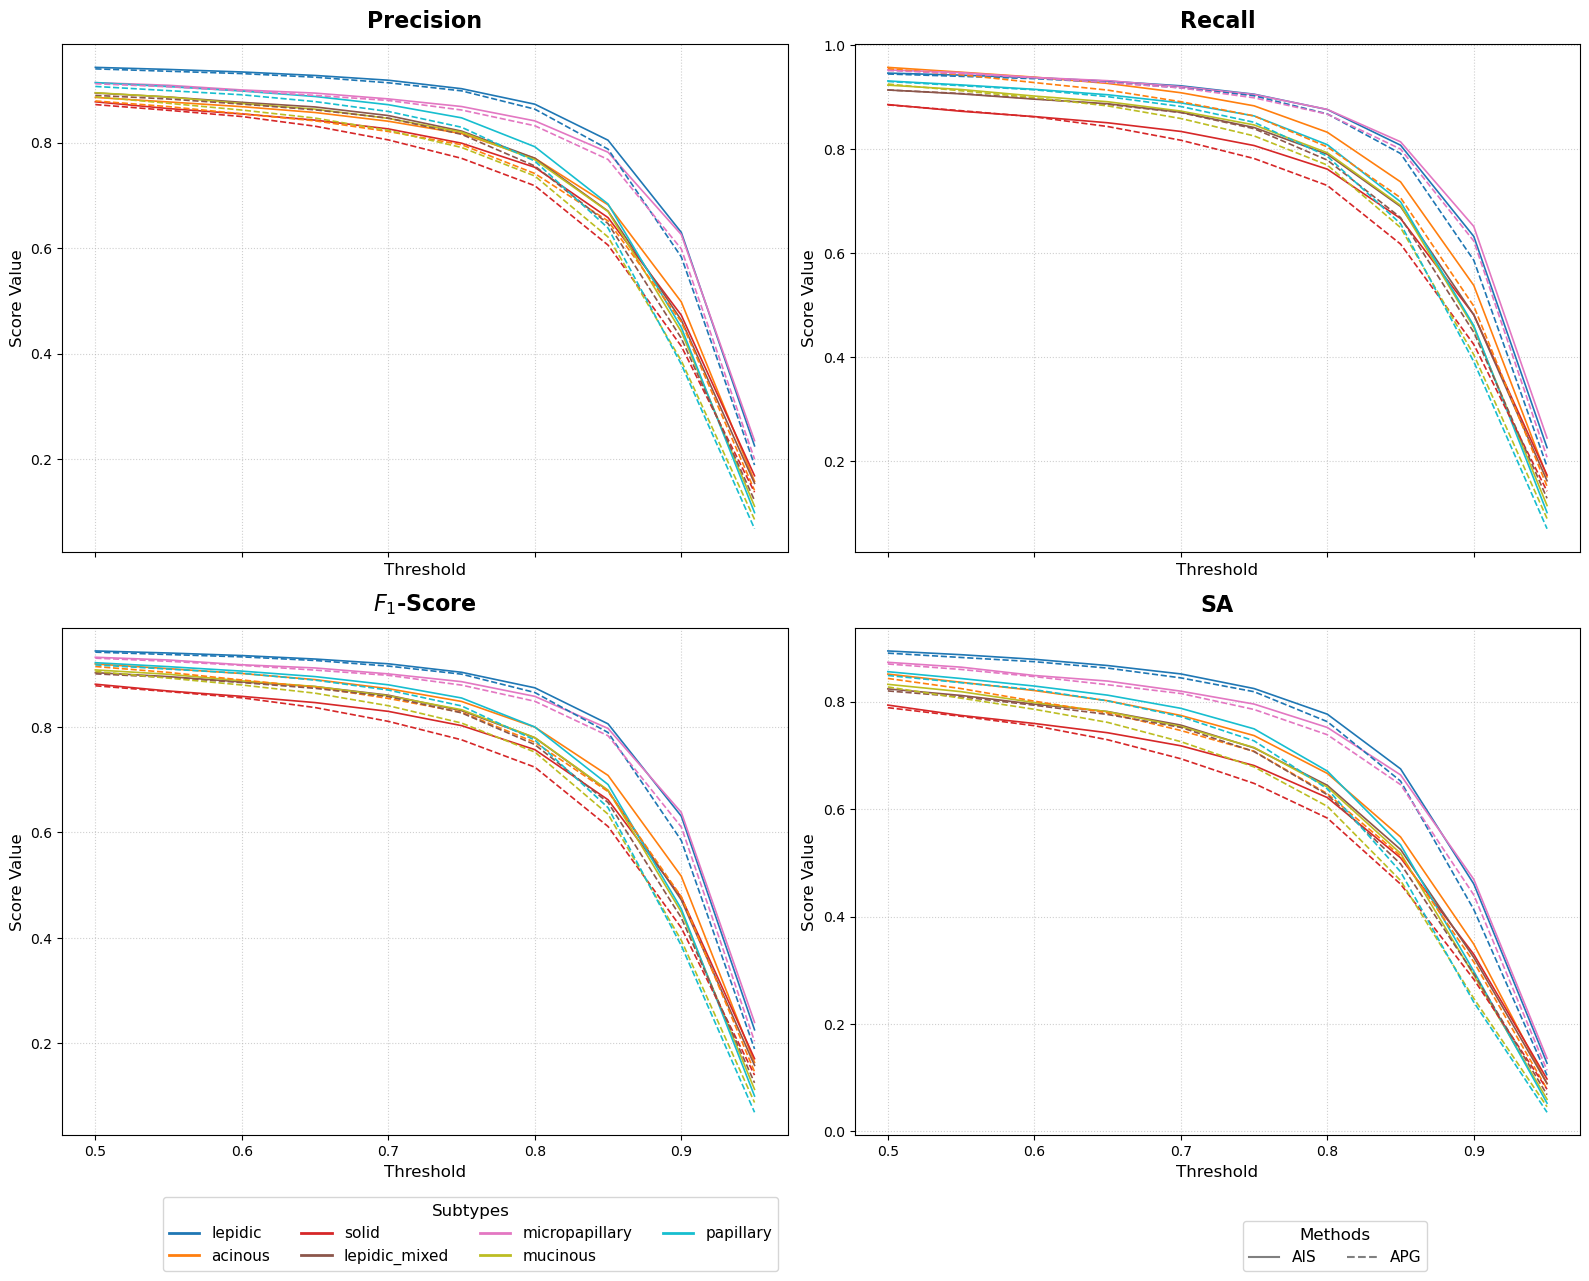

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Metrics configuration
scores = ["Precision", "Recall", "F1", "SA"]
score_titles = {
    "Precision": "Precision", 
    "Recall": "Recall", 
    "F1": "$F_1$-Score", 
    "SA": "SA"
}

# 1. Bigger figure size for enhanced spatial separation
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

# Method line style mapping
method_styles = {
    "ais": "-",   # Continuous / Solid
    "apg": "--"   # Discontinuous / Dashed
}

# Unique subtypes configuration
unique_subtypes = [k for k in specialist_results["ais"]["Precision"].keys() if k != "Threshold"]
color_palette = plt.cm.tab10(np.linspace(0, 1, len(unique_subtypes)))
subtype_colors = dict(zip(unique_subtypes, color_palette))

# Plotting Loop
for idx, score in enumerate(scores):
    ax = axes[idx]
    ax.set_title(score_titles[score], fontsize=16, fontweight='bold', pad=12)
    
    for method in ["ais", "apg"]:
        style = method_styles[method]
        res_dict = specialist_results[method][score]
        
        if "Threshold" not in res_dict:
            continue
        thresholds = res_dict["Threshold"]
        
        for subtype in unique_subtypes:
            if subtype in res_dict and len(res_dict[subtype]) > 0:
                # Average across multiple runs if necessary
                mean_values = np.mean(res_dict[subtype], axis=0)
                
                # 2. Made lines less thick (linewidth=1.2) for crisp visual separation
                ax.plot(
                    thresholds, 
                    mean_values, 
                    linestyle=style, 
                    color=subtype_colors[subtype],
                    linewidth=1.2
                )
                
    ax.set_xlabel("IoU Threshold", fontsize=12)
    ax.set_ylabel("Score Value", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

# 3. Custom Legend 1: Unique Subtypes (only maps colors to names)
subtype_handles = [
    Line2D([0], [0], color=subtype_colors[sub], lw=2, label=sub)
    for sub in unique_subtypes
]
leg_subtypes = fig.legend(
    handles=subtype_handles, 
    title="Subtypes", 
    loc='lower left', 
    bbox_to_anchor=(0.1, -0.07), 
    ncol=min(4, len(unique_subtypes)), 
    fontsize=11, 
    title_fontsize=12
)

# 4. Custom Legend 2: Method representation in grey
method_handles = [
    Line2D([0], [0], color='grey', linestyle='-', lw=1.5, label='AIS'),
    Line2D([0], [0], color='grey', linestyle='--', lw=1.5, label='APG')
]
leg_methods = fig.legend(
    handles=method_handles, 
    title="Methods", 
    loc='lower right', 
    bbox_to_anchor=(0.9, -0.07), 
    ncol=2, 
    fontsize=11, 
    title_fontsize=12
)

plt.tight_layout()
plt.savefig("specialist_method_comparison_refined.png", bbox_inches="tight")

In [36]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Metrics configuration
scores = ["Precision", "Recall", "F1", "SA"]
score_titles = {
    "Precision": "Precision", 
    "Recall": "Recall", 
    "F1": "$F_1$-Score", 
    "SA": "SA"
}

# Method line style mapping
method_styles = {
    "ais": "-",   # Continuous / Solid
    "apg": "--"   # Discontinuous / Dashed
}

# Unique subtypes configuration
unique_subtypes = [k for k in specialist_results["ais"]["Precision"].keys() if k != "Threshold"]
color_palette = plt.cm.tab10(np.linspace(0, 1, len(unique_subtypes)))
subtype_colors = dict(zip(unique_subtypes, color_palette))

# Generate separate plots one after another
for score in scores:
    # Creating a single large figure per score for maximum visual room
    fig, ax = plt.subplots(figsize=(12, 8))
    
    ax.set_title(score_titles[score], fontsize=16, fontweight='bold', pad=14)
    
    for method in ["ais", "apg"]:
        style = method_styles[method]
        res_dict = specialist_results[method][score]
        
        if "Threshold" not in res_dict:
            continue
        thresholds = res_dict["Threshold"]
        
        for subtype in unique_subtypes:
            if subtype in res_dict and len(res_dict[subtype]) > 0:
                # Average across multiple runs if necessary
                mean_values = np.mean(res_dict[subtype], axis=0)
                
                # Thin lines for visual precision
                ax.plot(
                    thresholds, 
                    mean_values, 
                    linestyle=style, 
                    color=subtype_colors[subtype],
                    linewidth=1.2
                )
                
    ax.set_xlabel("Threshold", fontsize=12)
    ax.set_ylabel("Score Value", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

    # 1. Unique Subtype Legend (Placed just outside the right border)
    subtype_handles = [
        Line2D([0], [0], color=subtype_colors[sub], lw=2, label=sub)
        for sub in unique_subtypes
    ]
    leg_subtypes = ax.legend(
        handles=subtype_handles, 
        title="Subtypes", 
        loc='upper left', 
        bbox_to_anchor=(1.02, 1), 
        fontsize=11, 
        title_fontsize=12
    )
    
    # 2. Distinct Method Legend in grey (Placed lower right outside border)
    method_handles = [
        Line2D([0], [0], color='grey', linestyle='-', lw=1.5, label='AIS (Continuous)'),
        Line2D([0], [0], color='grey', linestyle='--', lw=1.5, label='APG (Discontinuous)')
    ]
    leg_methods = ax.legend(
        handles=method_handles, 
        title="Methods", 
        loc='lower left', 
        bbox_to_anchor=(1.02, 0), 
        fontsize=11, 
        title_fontsize=12
    )
    
    # Re-add the first legend (since the second call overrides it dynamically)
    ax.add_artist(leg_subtypes)
    
    # Adjust layout and save each figure cleanly
    plt.tight_layout()
    plt.savefig(f"specialist_{score.lower()}_comparison.png", bbox_inches="tight")
    plt.close(fig)

In [55]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Metrics configuration
scores = ["Precision", "Recall", "F1", "SA"]
score_titles = {
    "Precision": "Precision", 
    "Recall": "Recall", 
    "F1": "$F_1$-Score", 
    "SA": "SA"
}

# Method line style mapping (APG Specialist vs APG Generalist)
method_styles = {
    "specialist": "-",   # Specialist is Continuous / Solid
    "generalist": "--"   # Generalist is Discontinuous / Dashed
}

# Unique subtypes configuration (Extracted from the APG data)
unique_subtypes = [k for k in specialist_results["apg"]["Precision"].keys() if k != "Threshold"]
color_palette = plt.cm.tab10(np.linspace(0, 1, len(unique_subtypes)))
subtype_colors = dict(zip(unique_subtypes, color_palette))

# Generate separate plots one after another
for score in scores:
    # Creating a single large figure per score for maximum visual room
    fig, ax = plt.subplots(figsize=(12, 8))
    
    ax.set_title(score_titles[score], fontsize=16, fontweight='bold', pad=14)
    
    # Evaluate specialist vs generalist for APG
    for model_type in ["specialist", "generalist"]:
        style = method_styles[model_type]
        
        # Select the correct data dictionary dynamically
        if model_type == "specialist":
            res_dict = specialist_results["ais"][score]
        else:
            res_dict = generalist_results["apg"][score]
            
        if "Threshold" not in res_dict:
            continue
        thresholds = res_dict["Threshold"]
        
        for subtype in unique_subtypes:
            if subtype in res_dict and len(res_dict[subtype]) > 0:
                # Average across multiple runs if necessary
                mean_values = np.mean(res_dict[subtype], axis=0)
                
                # Thin lines for visual precision
                ax.plot(
                    thresholds, 
                    mean_values, 
                    linestyle=style, 
                    color=subtype_colors[subtype],
                    linewidth=1.2
                )
                
    ax.set_xlabel("Threshold", fontsize=12)
    ax.set_ylabel("Score Value", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

    # 1. Unique Subtype Legend (Only colors, no model type suffixes)
    subtype_handles = [
        Line2D([0], [0], color=subtype_colors[sub], lw=2, label=sub)
        for sub in unique_subtypes
    ]
    leg_subtypes = ax.legend(
        handles=subtype_handles, 
        title="Subtypes", 
        loc='upper left', 
        bbox_to_anchor=(1.02, 1), 
        fontsize=11, 
        title_fontsize=12
    )
    
    # 2. Distinct Model Type Legend represented in grey
    method_handles = [
        Line2D([0], [0], color='grey', linestyle='-', lw=1.5, label='AIS Specialist'),
        Line2D([0], [0], color='grey', linestyle='--', lw=1.5, label='APG Generalist')
    ]
    leg_methods = ax.legend(
        handles=method_handles, 
        title="Models", 
        loc='lower left', 
        bbox_to_anchor=(1.02, 0), 
        fontsize=11, 
        title_fontsize=12
    )
    
    # Re-add the first legend back onto the canvas
    ax.add_artist(leg_subtypes)
    
    # Save each figure cleanly as its own standalone file
    plt.tight_layout()
    plt.savefig(f"apg_specialist_vs_generalist_{score.lower()}.png", bbox_inches="tight")
    plt.close(fig)

In [52]:
generalist_results["apg"][score]

defaultdict(list,
            {'lepidic_mixed': [array([0.87837838, 0.8722449 , 0.86539244, 0.86009732, 0.85783718,
                     0.8518369 , 0.85108959, 0.84885127, 0.84661836, 0.84439083]),
              array([0.93716578, 0.93457944, 0.93457944, 0.93071286, 0.9255814 ,
                     0.9255814 , 0.92302588, 0.92302588, 0.92302588, 0.9192053 ])],
             'Threshold': array([0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95]),
             'acinous': [array([0.96540881, 0.96540881, 0.96540881, 0.96335079, 0.95924765,
                     0.95720251, 0.953125  , 0.953125  , 0.953125  , 0.953125  ]),
              array([0.9344113 , 0.92935832, 0.92520399, 0.92302468, 0.91976495,
                     0.91738149, 0.91500395, 0.91241698, 0.90919308, 0.90683578])],
             'micropapillary': [array([0.93564356, 0.93351648, 0.9250547 , 0.91666667, 0.90938687,
                     0.90628386, 0.90525176, 0.90422078, 0.90319091, 0.89805825]),
              array